In [ ]:
import requests
from google.cloud import storage
from google.colab import auth
from tqdm.auto import tqdm
import os
from google.colab import userdata
import json

# --- 1. Securely get the key from Colab Secrets ---
key_string = userdata.get('GCP_KEY')
key_data = json.loads(key_string)

# --- 2. Authenticate gsutil ---
with open('temp_key.json', 'w') as f:
    json.dump(key_data, f)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = 'temp_key.json'
!gcloud auth activate-service-account --key-file=temp_key.json

# --- 2. Configuration Variables ---
BUCKET_NAME = "asvspoof-la-data-bucket"

DOWNLOAD_URL = "https://zenodo.org/records/14498691/files/flac_E_aa.tar?download=1"

DESTINATION_BLOB_NAME = "ASVspoof5/flac_E_ae.tar"

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]


In [ ]:
!sudo pip3 install --no-cache-dir -U crcmod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for crcmod: filename=crcmod-1.7-cp312-cp312-linux_x86_64.whl size=31835 sha256=6d882c1f98dbbaf64ff90f77a49f0d87c5d55d1b92fa6c4fc308eb50017db6d3
  Stored in directory: /tmp/pip-ephem-wheel-cache-lvjpt8g9/wheels/76/08/0b/caa8b1380122cbfe6a03eaccbec0f63c67e619af4e30ca5e2a
Successfully built crcmod


In [ ]:
import os
import tarfile
import pandas as pd
import tensorflow as tf
import numpy as np
from tqdm.auto import tqdm

# --- Configuration ---
GCS_TAR_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/flac_E_ae.tar"
LOCAL_TAR_PATH = "/content/flac_E_ae.tar"

EXTRACT_PATH = "/content/flac_E_eval"

PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("✅ Configuration set.")

✅ Configuration set.


In [ ]:
#!gsutil help crcmod
#!sudo pip3 uninstall crcmod
#!sudo pip3 install --no-cache-dir -U crcmod
!rm -rf '/content/flac_E_eval'

In [ ]:
# --- Extract Audio Files ---

if not os.path.exists(LOCAL_TAR_PATH):
    print(f"Copying {GCS_TAR_PATH} to local disk...")
    !gsutil cp {GCS_TAR_PATH} {LOCAL_TAR_PATH}

if not os.path.exists(EXTRACT_PATH):
    print(f"Extracting {LOCAL_TAR_PATH}...")
    with tarfile.open(LOCAL_TAR_PATH) as tar:
        tar.extractall(path="/content")
    print("✅ Extraction complete.")
else:
    print("✅ Files already extracted.")

extracted_files = os.listdir(EXTRACT_PATH)
print(f"Found {len(extracted_files)} files in {EXTRACT_PATH}")
print(f"Example file: {extracted_files[0]}")

Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar to local disk...
Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar...
\ [1 files][  7.9 GiB/  7.9 GiB]   67.2 MiB/s                                   
Operation completed over 1 objects/7.9 GiB.                                      
Extracting /content/flac_E_ae.tar...


/tmp/ipython-input-1070124683.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


✅ Extraction complete.
Found 68188 files in /content/flac_E_eval
Example file: E_0004269163.flac


In [ ]:
import pandas as pd
import os

# --- Configuration ---
EXTRACT_PATH = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("Loading protocol...")

column_names = [
    'SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC',
    'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP'
]

df = pd.read_csv(
    PROTOCOL_PATH,
    sep=' ',
    names=column_names,
    storage_options={'token': 'temp_key.json'}
)

extracted_files = os.listdir(EXTRACT_PATH)
available_files_set = set([f.replace('.flac', '') for f in extracted_files])

test_df = df[df['AUDIO_FILE_NAME'].isin(available_files_set)].copy()

test_df['LABEL'] = test_df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

print(f"✅ Protocol Loaded.")
print(f"   Total files to test: {len(test_df)}")
print(f"   Breakdown: {test_df['KEY'].value_counts().to_dict()}")

Loading protocol...
✅ Protocol Loaded.
   Total files to test: 68188
   Breakdown: {'spoof': 54017, 'bonafide': 14171}


# Preprocessing

In [ ]:
import tensorflow as tf
import numpy as np

MAX_TIME_FRAMES = 400
N_MELS = 128

def preprocess_for_cnn_fixed(log_mel_spec):
    """
    Replicates partner's logic:
    1. Truncate if > 400
    2. Zero-pad if < 400
    3. Add channel dim
    """

    spec = log_mel_spec[:MAX_TIME_FRAMES, :]

    current_len = tf.shape(spec)[0]
    padding_needed = MAX_TIME_FRAMES - current_len

    paddings = [[0, tf.maximum(0, padding_needed)], [0, 0]]
    spec = tf.pad(spec, paddings, "CONSTANT")

    spec = tf.expand_dims(spec, -1)

    spec.set_shape((MAX_TIME_FRAMES, N_MELS, 1))

    return spec

In [ ]:
import soundfile as sf
import os

MY_DATA_DIR = "/content/flac_E_eval"

def dual_stream_generator(file_paths, labels):
    for fpath, label in zip(file_paths, labels):
        audio, _ = sf.read(fpath)
        audio = audio.astype(np.float32)

        audio_tensor = tf.convert_to_tensor(audio)
        stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
        spectrograms = tf.abs(stfts)
        linear_to_mel = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
        mel_spec = tf.tensordot(spectrograms, linear_to_mel, 1)
        log_mel = tf.math.log(mel_spec + 1e-6)

        rnn_in = log_mel

        cnn_in = preprocess_for_cnn_fixed(log_mel)

        yield {'rnn_input': rnn_in, 'cnn_input': cnn_in}, label

def build_joint_ds(paths, labels):
    ds = tf.data.Dataset.from_generator(
        lambda: dual_stream_generator(paths, labels),
        output_signature=(
            {
                'rnn_input': tf.TensorSpec(shape=(None, 128), dtype=tf.float32),
                'cnn_input': tf.TensorSpec(shape=(400, 128, 1), dtype=tf.float32)
            },
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    ds = ds.padded_batch(8, padded_shapes=(
        {'rnn_input': [None, 128], 'cnn_input': [400, 128, 1]},
        []
    ))
    return ds.prefetch(tf.data.AUTOTUNE)

# Training Dual Model

In [ ]:
from tensorflow.keras import layers, models, Input

RNN_MODEL_PATH = f"gs://{BUCKET_NAME}/models/best_model_eval_df.keras"
CNN_MODEL_PATH = f"gs://{BUCKET_NAME}/models/best_cnn_model_eval_df.keras"

print("Loading models...")
rnn_full = models.load_model(RNN_MODEL_PATH)
cnn_full = models.load_model(CNN_MODEL_PATH)

for i, layer in enumerate(rnn_full.layers):
    layer._name = f"rnn_{i}_{layer.name}".replace(":", "_")

for i, layer in enumerate(cnn_full.layers):
    layer._name = f"cnn_{i}_{layer.name}".replace(":", "_")

print("✅ Layers renamed to avoid collisions.")

input_a = Input(shape=(None, 128), name='rnn_input_safe')
input_b = Input(shape=(400, 128, 1), name='cnn_input_safe')

x = input_a
for layer in rnn_full.layers[:-1]:
    layer.trainable = False
    x = layer(x)
feat_a = x

y = input_b
for layer in cnn_full.layers[:-1]:
    layer.trainable = False
    y = layer(y)
feat_b = y

concat = layers.Concatenate(name='manager_concat')([feat_a, feat_b])

z = layers.Dense(64, activation='relu', name='manager_dense_1')(concat)
z = layers.Dropout(0.3, name='manager_dropout_1')(z)
output = layers.Dense(1, activation='sigmoid', name='manager_output')(z)

super_model = models.Model(inputs=[input_a, input_b], outputs=output)

super_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Super-Model successfully built without errors!")
super_model.summary()

Loading models...
✅ Layers renamed to avoid collisions.
✅ Super-Model successfully built without errors!


Model: "functional_131"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input_safe      │ (None, 400, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 400, 128,  │        320 │ cnn_input_safe[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128,  │        128 │ conv2d_9[13][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 200, 64,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_input_safe      │ (None, None, 128) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 200, 64,   │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_52        │ (None, None, 128) │          0 │ rnn_input_safe[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64,   │        256 │ conv2d_10[10][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 128) │          0 │ rnn_input_safe[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_52 (Any)        │ (None, None)      │          0 │ not_equal_52[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 100, 32,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, None, 256) │    198,144 │ masking[8][0],    │
│ (Bidirectional)     │                   │            │ any_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 100, 32,   │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 256) │          0 │ bidirectional[7]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32,   │        512 │ conv2d_11[7][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    123,648 │ dropout[6][0],    │
│ (Bidirectional)     │                   │            │ any_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 50, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[

 Total params: 452,545 (1.73 MB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 440,128 (1.68 MB)

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# --- Configuration ---
DATA_DIR = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"
BATCH_SIZE = 32

# --- 1. Load & Filter Protocol ---
print("📜 Loading Protocol...")
cols = ['SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC', 'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP']

try:
    df = pd.read_csv(PROTOCOL_PATH, sep=' ', names=cols, storage_options={'token': 'temp_key.json'})
except:
    df = pd.read_csv("ASVspoof5.eval.track_1.tsv", sep=' ', names=cols)

available_files = set([f.replace('.flac', '') for f in os.listdir(DATA_DIR)])
df = df[df['AUDIO_FILE_NAME'].isin(available_files)].copy()

df['LABEL'] = df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

print(f"✅ Ready to train on {len(df)} files.")
print(f"   Bonafide: {len(df[df['LABEL']==0])} | Spoof: {len(df[df['LABEL']==1])}")

# --- 2. Stratified 3-Way Split (70/15/15) ---
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['LABEL']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['LABEL']
)

print(f"✂️ Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# --- 3. Compute Class Weights ---
labels = train_df['LABEL'].values
class_weights_arr = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights_arr))
print(f"⚖️ Class Weights: {class_weights}")

📜 Loading Protocol...
✅ Ready to train on 68188 files.
   Bonafide: 14171 | Spoof: 54017
✂️ Split: Train=47731, Val=10228, Test=10229
⚖️ Class Weights: {0: np.float64(2.405796370967742), 1: np.float64(0.63117875750443)}


In [ ]:
# --- 4. The Generator & Dataset ---
def dual_stream_generator(filenames, labels):
    for fname, label in zip(filenames, labels):
        fpath = os.path.join(DATA_DIR, fname + ".flac")
        try:
            audio, _ = sf.read(fpath)
            audio = audio.astype(np.float32)

            # --- Base Spectrogram ---
            audio_tensor = tf.convert_to_tensor(audio)
            stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
            spectrograms = tf.abs(stfts)
            linear_to_mel = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
            mel_spec = tf.tensordot(spectrograms, linear_to_mel, 1)
            log_mel = tf.math.log(mel_spec + 1e-6)

            # --- Input A: RNN ---
            rnn_in = log_mel

            # --- Input B: CNN ---
            cnn_in = log_mel[:400, :]
            paddings = [[0, tf.maximum(0, 400 - tf.shape(cnn_in)[0])], [0, 0]]
            cnn_in = tf.pad(cnn_in, paddings, "CONSTANT")
            cnn_in = tf.expand_dims(cnn_in, -1)
            cnn_in.set_shape((400, 128, 1))

            yield {'rnn_input_safe': rnn_in, 'cnn_input_safe': cnn_in}, label

        except Exception as e:
            continue

def create_tf_dataset(dataframe):
    ds = tf.data.Dataset.from_generator(
        lambda: dual_stream_generator(dataframe['AUDIO_FILE_NAME'], dataframe['LABEL']),
        output_signature=(
            {'rnn_input_safe': tf.TensorSpec(shape=(None, 128), dtype=tf.float32),
             'cnn_input_safe': tf.TensorSpec(shape=(400, 128, 1), dtype=tf.float32)},
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )
    return ds.padded_batch(BATCH_SIZE, padded_shapes=(
        {'rnn_input_safe': [None, 128], 'cnn_input_safe': [400, 128, 1]}, []
    )).prefetch(tf.data.AUTOTUNE)

train_ds = create_tf_dataset(train_df)
val_ds = create_tf_dataset(val_df)
test_ds = create_tf_dataset(test_df)

In [ ]:
# --- 5. Feature Extraction (The Speed Fix) ---
feature_extractor = models.Model(
    inputs=super_model.input,
    outputs=super_model.get_layer('manager_concat').output
)

def cache_data(dataset, desc="Extracting"):
    feats_list, labs_list = [], []
    for x_batch, y_batch in tqdm(dataset, desc=desc):
        feats = feature_extractor.predict_on_batch(x_batch)
        feats_list.append(feats)
        labs_list.append(y_batch.numpy())
    return np.vstack(feats_list), np.hstack(labs_list)

print("\n⏳ Starting Feature Caching (This takes time, but only ONCE)...")
X_train, y_train = cache_data(train_ds, "Train Set")
X_val, y_val     = cache_data(val_ds, "Val Set")
X_test, y_test   = cache_data(test_ds, "Test Set")

# --- 6. Build & Train Lightweight Manager ---
print("\n🚀 Training Manager on Cached Features...")


⏳ Starting Feature Caching (This takes time, but only ONCE)...


Train Set: 0it [00:00, ?it/s]

Val Set: 0it [00:00, ?it/s]

Test Set: 0it [00:00, ?it/s]


🚀 Training Manager on Cached Features...


In [ ]:
EPOCHS = 50

# Simple Manager Model
inp = Input(shape=(192,))
x = layers.Dense(64, activation='relu')(inp)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='sigmoid')(x)
manager_model = models.Model(inputs=inp, outputs=out)

manager_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
# Train
history = manager_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=512,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True)
    ]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5668 - auc: 0.6917 - loss: 0.6147 - val_accuracy: 0.9400 - val_auc: 0.9930 - val_loss: 0.2586
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9404 - auc: 0.9911 - loss: 0.2144 - val_accuracy: 0.9607 - val_auc: 0.9956 - val_loss: 0.1432
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9584 - auc: 0.9947 - loss: 0.1323 - val_accuracy: 0.9678 - val_auc: 0.9967 - val_loss: 0.1052
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9641 - auc: 0.9958 - loss: 0.1025 - val_accuracy: 0.9728 - val_auc: 0.9974 - val_loss: 0.0863
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9701 - auc: 0.9966 - loss: 0.0860 - val_accuracy: 0.9758 - val_auc: 0.9977 - val_loss: 0.0752
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9735 - auc: 0.9970 - loss: 0.0759 - val_accuracy: 0.9768 - val_auc: 0.9980 - val_loss: 0.0678
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

In [ ]:
# --- 7. Evaluation ---
print("\n🏆 Final Exam Results:")
results = manager_model.evaluate(X_test, y_test)
print(f"   Test AUC: {results[2]:.4f}")

# --- 8. Save Weights Back to Super Model ---
super_model.get_layer('manager_dense_1').set_weights(manager_model.layers[1].get_weights())
super_model.get_layer('manager_output').set_weights(manager_model.layers[3].get_weights())
super_model.save(f"gs://{BUCKET_NAME}/models/synthesized_model_eval_df.keras")
print("✅ Full pipeline saved!")


🏆 Final Exam Results:
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9816 - auc: 0.9979 - loss: 0.0521
   Test AUC: 0.9980
✅ Full pipeline saved!


# Testing

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import soundfile as sf
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
NEW_DATA_DIR = "/content/flac_E_eval"
MODEL_PATH = f"gs://{BUCKET_NAME}/models/synthesized_model_eval_df.keras"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"
BATCH_SIZE = 32

# --- 1. Load Model ---
print(f"🧠 Loading Super-Model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

# --- 2. Prepare File List & Protocol ---
print("📂 Scanning files and matching Protocol...")

files_on_disk = set([f.replace('.flac', '') for f in os.listdir(NEW_DATA_DIR) if f.endswith('.flac')])

cols = ['SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC', 'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP']
try:
    df = pd.read_csv(PROTOCOL_PATH, sep=' ', names=cols, storage_options={'token': 'temp_key.json'})
except:
    df = pd.read_csv("ASVspoof5.eval.track_1.tsv", sep=' ', names=cols)


test_df = df[df['AUDIO_FILE_NAME'].isin(files_on_disk)].copy()
test_df['LABEL'] = test_df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

print(f"✅ Found {len(test_df)} files in the new shard.")
print(f"   Bonafide: {len(test_df[test_df['LABEL']==0])} | Spoof: {len(test_df[test_df['LABEL']==1])}")

🧠 Loading Super-Model from gs://asvspoof-la-data-bucket/models/synthesized_model_eval_df.keras...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📂 Scanning files and matching Protocol...
✅ Found 68188 files in the new shard.
   Bonafide: 13994 | Spoof: 54194


In [ ]:
# --- 3. Define Preprocessing ---
def inference_generator(filenames):
    for fname in filenames:
        fpath = os.path.join(NEW_DATA_DIR, fname + ".flac")
        try:
            audio, _ = sf.read(fpath)
            audio = audio.astype(np.float32)

            audio_tensor = tf.convert_to_tensor(audio)
            stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
            spectrograms = tf.abs(stfts)
            linear_to_mel = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
            mel_spec = tf.tensordot(spectrograms, linear_to_mel, 1)
            log_mel = tf.math.log(mel_spec + 1e-6)

            # Input A: RNN
            rnn_in = log_mel

            # Input B: CNN (Fixed 400)
            cnn_in = log_mel[:400, :]
            paddings = [[0, tf.maximum(0, 400 - tf.shape(cnn_in)[0])], [0, 0]]
            cnn_in = tf.pad(cnn_in, paddings, "CONSTANT")
            cnn_in = tf.expand_dims(cnn_in, -1)
            cnn_in.set_shape((400, 128, 1))

            yield {'rnn_input_safe': rnn_in, 'cnn_input_safe': cnn_in}

        except Exception as e:
            print(f"⚠️ Error reading {fname}: {e}")

# Build TF Dataset
def create_inference_ds(file_list):
    ds = tf.data.Dataset.from_generator(
        lambda: inference_generator(file_list),
        output_signature={
            'rnn_input_safe': tf.TensorSpec(shape=(None, 128), dtype=tf.float32),
            'cnn_input_safe': tf.TensorSpec(shape=(400, 128, 1), dtype=tf.float32)
        }
    )
    # Batching
    ds = ds.padded_batch(BATCH_SIZE, padded_shapes={
        'rnn_input_safe': [None, 128], 'cnn_input_safe': [400, 128, 1]
    })
    return ds.prefetch(tf.data.AUTOTUNE)

# --- 4. Run Prediction ---
print("\n🚀 Running Inference on New Shard...")
ds = create_inference_ds(test_df['AUDIO_FILE_NAME'])


🚀 Running Inference on New Shard...


In [ ]:
# Predict
y_pred_probs = model.predict(ds, verbose=1)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_df['LABEL'].values

2131/2131 ━━━━━━━━━━━━━━━━━━━━ 1966s 922ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



🏆 NEW SHARD RESULTS (Part 2)
AUC Score:      0.9952
Accuracy:       97.03%
----------------------------------------


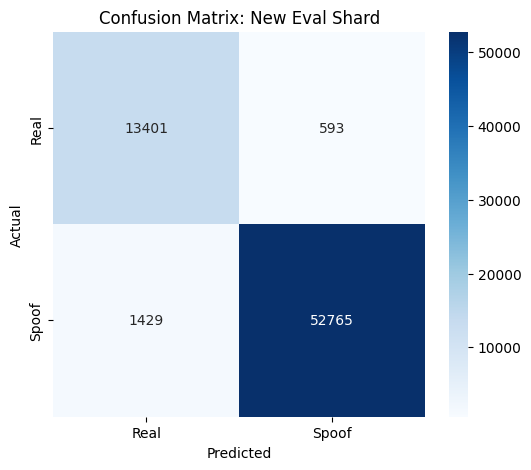

In [ ]:
# --- 5. Final Report ---
auc = roc_auc_score(y_true, y_pred_probs)
acc = accuracy_score(y_true, y_pred_classes)
cm = confusion_matrix(y_true, y_pred_classes)

print("\n" + "="*40)
print(f"🏆 NEW SHARD RESULTS (Part 2)")
print("="*40)
print(f"AUC Score:      {auc:.4f}")
print(f"Accuracy:       {acc*100:.2f}%")
print("-" * 40)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Spoof'], yticklabels=['Real', 'Spoof'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: New Eval Shard')
plt.show()

In [ ]:
# --- 6. Save Predictions (Optional) ---
test_df['PRED_PROB'] = y_pred_probs
test_df['PRED_CLASS'] = y_pred_classes
test_df.to_csv("shard2_predictions.csv", index=False)
print("\n📄 Detailed predictions saved to 'shard2_predictions.csv'")

# Inference on Custom Dataset

In [ ]:
!rm -rf '/content/voice_auth_data'

In [ ]:
!unzip voice_auth_data.zip

Archive:  voice_auth_data.zip
   creating: voice_auth_data/
  inflating: __MACOSX/._voice_auth_data  
  inflating: voice_auth_data/.DS_Store  
  inflating: __MACOSX/voice_auth_data/._.DS_Store  
   creating: voice_auth_data/bonafide/
  inflating: __MACOSX/voice_auth_data/._bonafide  
   creating: voice_auth_data/spoof/
  inflating: __MACOSX/voice_auth_data/._spoof  
  inflating: voice_auth_data/bonafide/real_07.flac  
  inflating: voice_auth_data/bonafide/real_50.flac  
  inflating: voice_auth_data/bonafide/real_46.flac  
  inflating: voice_auth_data/bonafide/real_11.flac  
  inflating: voice_auth_data/bonafide/real_31.flac  
  inflating: voice_auth_data/bonafide/real_27.flac  
  inflating: voice_auth_data/bonafide/real_26.flac  
  inflating: voice_auth_data/bonafide/real_30.flac  
  inflating: voice_auth_data/bonafide/real_10.flac  
  inflating: voice_auth_data/bonafide/real_47.flac  
  inflating: voice_auth_data/bonafide/real_51.flac  
  inflating: voice_auth_data/bonafide/real_06.fl

In [ ]:
import os
import numpy as np
import tensorflow as tf
import soundfile as sf
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuration ---
MY_DATA_DIR = "/content/voice_auth_data"
BONAFIDE_DIR = os.path.join(MY_DATA_DIR, "bonafide")
SPOOF_DIR = os.path.join(MY_DATA_DIR, "spoof")
MODEL_PATH = f"gs://{BUCKET_NAME}/models/synthesized_model_eval_df.keras"
BATCH_SIZE = 8

In [ ]:
# --- 1. Gather Files & Labels ---
print("📂 Scanning personal dataset...")
file_paths = []
labels = []

if os.path.exists(BONAFIDE_DIR):
    real_files = [os.path.join(BONAFIDE_DIR, f) for f in os.listdir(BONAFIDE_DIR) if f.endswith(('.flac', '.wav'))]
    file_paths.extend(real_files)
    labels.extend([0] * len(real_files))

if os.path.exists(SPOOF_DIR):
    spoof_files = [os.path.join(SPOOF_DIR, f) for f in os.listdir(SPOOF_DIR) if f.endswith(('.flac', '.wav'))]
    file_paths.extend(spoof_files)
    labels.extend([1] * len(spoof_files))

file_paths = np.array(file_paths)
labels = np.array(labels)

print(f"✅ Found {len(file_paths)} files.")
print(f"   Bonafide (Real): {np.sum(labels==0)}")
print(f"   Spoof (Fake):    {np.sum(labels==1)}")

if len(file_paths) == 0:
    raise ValueError("No files found! Check your folder structure.")

📂 Scanning personal dataset...
✅ Found 103 files.
   Bonafide (Real): 53
   Spoof (Fake):    50


In [ ]:
# --- 2. Define Preprocessing (Must match training exactly) ---
def inference_generator(paths):
    for fpath in paths:
        try:
            audio, _ = sf.read(fpath)
            audio = audio.astype(np.float32)

            # --- Base Spectrogram ---
            audio_tensor = tf.convert_to_tensor(audio)
            stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
            spectrograms = tf.abs(stfts)
            linear_to_mel = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
            mel_spec = tf.tensordot(spectrograms, linear_to_mel, 1)
            log_mel = tf.math.log(mel_spec + 1e-6)

            # --- Input A: RNN ---
            rnn_in = log_mel

            # --- Input B: CNN (Fixed 400) ---
            cnn_in = log_mel[:400, :]
            paddings = [[0, tf.maximum(0, 400 - tf.shape(cnn_in)[0])], [0, 0]]
            cnn_in = tf.pad(cnn_in, paddings, "CONSTANT")
            cnn_in = tf.expand_dims(cnn_in, -1)
            cnn_in.set_shape((400, 128, 1))

            yield {'rnn_input_safe': rnn_in, 'cnn_input_safe': cnn_in}

        except Exception as e:
            print(f"⚠️ Error reading {fpath}: {e}")

# Build TF Dataset
def create_test_ds(paths):
    ds = tf.data.Dataset.from_generator(
        lambda: inference_generator(paths),
        output_signature={
            'rnn_input_safe': tf.TensorSpec(shape=(None, 128), dtype=tf.float32),
            'cnn_input_safe': tf.TensorSpec(shape=(400, 128, 1), dtype=tf.float32)
        }
    )
    ds = ds.padded_batch(BATCH_SIZE, padded_shapes={
        'rnn_input_safe': [None, 128], 'cnn_input_safe': [400, 128, 1]
    })
    return ds

In [ ]:
# --- 3. Run Inference ---
print("\n🧠 Loading Model & Predicting...")
model = tf.keras.models.load_model(MODEL_PATH)
test_ds = create_test_ds(file_paths)


🧠 Loading Model & Predicting...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Predict
y_pred_probs = model.predict(test_ds, verbose=1).flatten()
y_pred_classes = (y_pred_probs > 0.2).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



📊 PERSONAL DATASET REPORT
Accuracy: 84.47%
AUC Score: 0.9238
------------------------------

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.80      0.92      0.86        53
   Spoof (1)       0.90      0.76      0.83        50

    accuracy                           0.84       103
   macro avg       0.85      0.84      0.84       103
weighted avg       0.85      0.84      0.84       103



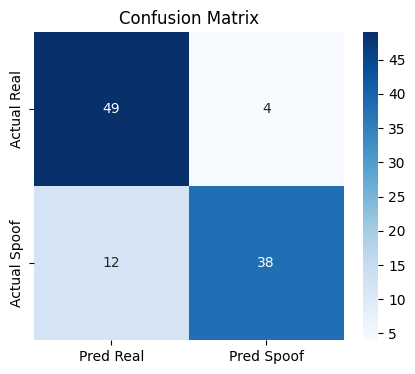

In [ ]:
# --- 4. Evaluate Performance ---
acc = accuracy_score(labels, y_pred_classes)
try:
    auc = roc_auc_score(labels, y_pred_probs)
except:
    auc = 0.5

print("\n" + "="*30)
print(f"📊 PERSONAL DATASET REPORT")
print("="*30)
print(f"Accuracy: {acc*100:.2f}%")
print(f"AUC Score: {auc:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(labels, y_pred_classes, target_names=['Real (0)', 'Spoof (1)']))

# --- 5. Visualizing Errors ---
cm = confusion_matrix(labels, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Spoof'],
            yticklabels=['Actual Real', 'Actual Spoof'])
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# --- 6. Show Specific Failures ---
print("\n🔍 Detailed Failure Analysis (Where did it go wrong?)")
print(f"{'FILENAME':<30} | {'ACTUAL':<10} | {'PRED':<10} | {'CONFIDENCE':<10}")
print("-" * 70)

for i in range(len(file_paths)):
    if labels[i] != y_pred_classes[i]:
        fname = os.path.basename(file_paths[i])
        act = "REAL" if labels[i] == 0 else "SPOOF"
        pred = "REAL" if y_pred_classes[i] == 0 else "SPOOF"
        conf = y_pred_probs[i]
        print(f"{fname:<30} | {act:<10} | {pred:<10} | {conf:.4f}")

if np.all(labels == y_pred_classes):
    print("🎉 Perfection! No errors found.")


🔍 Detailed Failure Analysis (Where did it go wrong?)
FILENAME                       | ACTUAL     | PRED       | CONFIDENCE
----------------------------------------------------------------------
real_23.flac                   | REAL       | SPOOF      | 0.9595
real_13.flac                   | REAL       | SPOOF      | 0.5593
real_18.flac                   | REAL       | SPOOF      | 0.3528
real_53.flac                   | REAL       | SPOOF      | 0.4927
spoof_01.flac                  | SPOOF      | REAL       | 0.0462
spoof_36.flac                  | SPOOF      | REAL       | 0.1472
spoof_42.flac                  | SPOOF      | REAL       | 0.0221
spoof_12.flac                  | SPOOF      | REAL       | 0.0943
spoof_11.flac                  | SPOOF      | REAL       | 0.1056
spoof_45.flac                  | SPOOF      | REAL       | 0.1618
spoof_32.flac                  | SPOOF      | REAL       | 0.0654
spoof_04.flac                  | SPOOF      | REAL       | 0.1098
spoof_02.flac